# Notebook 1: Data Exploration

**NYU Deep Learning Spring 2026 — Text-to-SVG Kaggle Competition**

### Purpose
Before training any model, we need to understand the data we are working with.
This notebook answers the following questions:

1. What do the prompts look like? How long are they?
2. What do the SVGs look like? How complex are they?
3. How long are the SVGs in characters + what does that mean for token budget?
4. Which training examples should we keep vs. filter out?
5. Are there any invalid or malformed SVGs in the training set?

The answers to these questions will directly determine our `max_seq_length`,
our dataset size, and our training strategy in Notebook 2.

### Competition constraint reminders
- Output SVGs must be **≤ 8,000 characters**
- Canvas must be **256×256 pixels**
- Max **256 path elements**
- Only specific tags allowed (svg, g, path, rect, circle, ellipse, line, polyline, polygon). No scripts, no animations.
- Any invalid SVG scores **zero** -> we need to hard gate this so they don't drag our score down

## 0. Install dependencies

In [1]:
# Install required packages.
# cairosvg: SVG renderer, rasterize SVG to PNG (same one used by the competition scorer + tutorial)
# datasets: HuggingFace library for loading the uploaded train/test data
%pip install -q cairosvg datasets pandas matplotlib

## 1. Load the data

We uploaded `train.csv` and `test.csv` to a public HuggingFace dataset repo.
Loading from HuggingFace means we don't need to manually upload files to Colab
every session and can just directly stream the data.

Since the dataset is public, no token is needed to load it.
If you want to use your own copy, change `HF_DATASET_REPO` to your repo path,
or set `USE_HUGGINGFACE = False` and point the local paths at your downloaded CSVs.

In [2]:
import os
import pandas as pd
from datasets import load_dataset

# DATA SOURCE
# Option A: load from HuggingFace (default, no token needed for public repos)
USE_HUGGINGFACE  = True
HF_DATASET_REPO  = "aagoluoglu/text-to-svg"

# Option B: load from local files
# Download train.csv and test.csv from the Kaggle competition page,
# place them in a data/ folder next to this notebook, then set USE_HUGGINGFACE = False
LOCAL_TRAIN_PATH = "data/train.csv"
LOCAL_TEST_PATH  = "data/test.csv"


if USE_HUGGINGFACE:
    dataset  = load_dataset(
        HF_DATASET_REPO,
        data_files={"train": "train.csv", "test": "test.csv"},
    )
    train_df = dataset["train"].to_pandas()
    test_df  = dataset["test"].to_pandas()
else:
    train_df = pd.read_csv(LOCAL_TRAIN_PATH)
    test_df  = pd.read_csv(LOCAL_TEST_PATH)

print(f"Train rows : {len(train_df):,}")
print(f"Test rows  : {len(test_df):,}")
print(f"\nTrain columns: {list(train_df.columns)}")
print(f"Test columns : {list(test_df.columns)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Train rows : 50,000
Test rows  : 1,000

Train columns: ['id', 'prompt', 'svg']
Test columns : ['id', 'prompt', 'svg']


## 2. Preview a few rows

It's best to look at raw data before doing anything else.
This catches encoding issues, unexpected columns, or obvious anomalies early. Learned this the hard way rip.

In [3]:
# Display the first few rows, truncate svg so it doesn't flood the output
display_df = train_df.copy()
display_df["svg"] = display_df["svg"].str[:80] + "..."
display(display_df.head(5))

,id,prompt,svg
0,fd61e324e0cec5c11f337d0bfe2858c8,The image features two orange squares with a m...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
1,999b3d4d5a860725bf9528910b5612f3,A simple smiley face with a wide open mouth an...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
2,1aaa84517819c25f783ae1c0cb337fc5,The image features a black-outlined icon of a ...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
3,919a7da8bd44dc7781dbe87383a268cc,The image displays a black icon with a photo-l...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
4,thesantatitan_deepseek-svg-dataset_0000581,Generate svg code for an image that looks like...,"<svg width=""24"" height=""24"" viewBox=""0 0 24 24..."


In [4]:
# Print one full example to see the actual SVG structure
# Pick a diff index to choose diff examples
EXAMPLE_IDX = 1

print("=" * 60)
print("PROMPT:")
print(train_df.loc[EXAMPLE_IDX, "prompt"])
print("\nSVG (first 500 chars):")
print(train_df.loc[EXAMPLE_IDX, "svg"][:500])
print("\nFull SVG length:", len(train_df.loc[EXAMPLE_IDX, "svg"]), "characters")

PROMPT:
A simple smiley face with a wide open mouth and straight eyes.

SVG (first 500 chars):
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="#040000" fill-opacity="1.0"  filling="0" d="M100.3030014038086 11.76300048828125 C51.808998107910156 11.76300048828125 12.494003295898438 51.07899856567383 12.494003295898438 99.58000183105469 C12.494003295898438 148.0760040283203 51.808998107910156 187.39199829101562 100.3030014038086 187.39199829101562 C148.79600524902344 187.39199829101562 188.1230010986328 148.0749969482422 188.

Full SVG length: 3166 characters


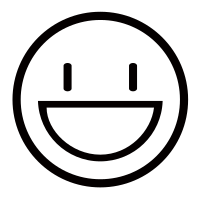

In [5]:
# Render the example SVG inline to visually confirm it looks right
# Use IPython's SVG display like tutorial notebook
from IPython.display import SVG, display
display(SVG(data=train_df.loc[EXAMPLE_IDX, "svg"]))

## 3. Check for missing or malformed data

Before computing any statistics, we need to know if the dataset has
nulls or empty strings that would corrupt our analysis.

In [6]:
print("Null values in train:")
print(train_df.isnull().sum())
print("\nNull values in test:")
print(test_df.isnull().sum())

Null values in train:
id        0
prompt    0
svg       0
dtype: int64

Null values in test:
id           0
prompt       0
svg       1000
dtype: int64


In [7]:
# Empty strings are different from null — check both
empty_prompts = (train_df["prompt"].str.strip() == "").sum()
empty_svgs    = (train_df["svg"].str.strip() == "").sum()
print(f"Empty prompts : {empty_prompts}")
print(f"Empty SVGs    : {empty_svgs}")

Empty prompts : 0
Empty SVGs    : 0


In [8]:
# Check that all SVGs start with '<svg'
# Competition requires valid XML with <svg as the root element
valid_start     = train_df["svg"].str.lstrip().str.lower().str.startswith("<svg")
n_invalid_start = (~valid_start).sum()
print(f"SVGs that don't start with <svg: {n_invalid_start}")
if n_invalid_start > 0:
    print("\nExamples of non-<svg starts:")
    print(train_df.loc[~valid_start, "svg"].str[:100].head(3).values)

SVGs that don't start with <svg: 0


## 4. Prompt analysis

Understanding the prompts tells shows what kinds of descriptions the model needs to handle. Ex: short icon descriptions or longer scene descriptions?

In [12]:
# Basic prompt length statistics
train_df["prompt_len"]   = train_df["prompt"].str.len()
train_df["prompt_words"] = train_df["prompt"].str.split().str.len()

print("Prompt character length:")
print(train_df["prompt_len"].describe().round(1))
print("\nPrompt word count:")
print(train_df["prompt_words"].describe().round(1))

Prompt character length:
count    50000.0
mean       116.6
std         64.2
min          5.0
25%         72.0
50%        103.0
75%        137.0
max        860.0
Name: prompt_len, dtype: float64

Prompt word count:
count    50000.0
mean        19.7
std         10.3
min          1.0
25%         12.0
50%         17.0
75%         24.0
max        127.0
Name: prompt_words, dtype: float64


In [13]:
# Print 10 random prompts to see general writing style and content
print("10 random training prompts:\n")
for i, prompt in enumerate(train_df["prompt"].sample(10, random_state=7).values):
    print(f"{i+1:2d}. {prompt}")

10 random training prompts:

 1. The image features a black power button icon on a white background, consisting of a circle with a vertical line segment inside it.
 2. The image features a black outline of a house shape with six white circles placed around it against a black background.
 3. The image consists of a red geometric logo with a central black rectangle surrounded by a stylized red circular shape.
 4. A black circular button with a white triangular play icon centered inside it.
 5. A black arrow icon pointing downwards and to the right on a white background.
 6. A black arrow pointing downward with a horizontal line beneath it.
 7. The image depicts the symbol for Venus, representing femininity or female gender.
 8. A black curved arrow pointing to the right, used for navigation or signposting in various contexts.
 9. A black hexagon with a white minus sign inside it.
10. The image contains a single color: solid black, filling the entire frame.


In [14]:
# Check the test prompts too, how similar in style to training?
# If very different, could need to be careful about prompt formatting during inference
print("10 random test prompts:\n")
for i, prompt in enumerate(test_df["prompt"].sample(10, random_state=7).values):
    print(f"{i+1:2d}. {prompt}")

10 random test prompts:

 1. The image features a single black icon resembling the letter 'g' composed of smooth, curved lines and shapes against a white background. The top of the 'g' includes a large black circle, while the bottom features an elongated oval shape. A curved line extends diagonally from the upper right to connect the elements, creating a continuous flow within the design.
 2. The image shows a black, symmetrical symbol composed of two teardrop-like shapes flanking a central vertical line, both supported by a horizontal line at the top and a small rectangular base at the bottom, set against a white background.
 3. The image contains black Cyrillic letters 'РУБ' (RUB) inside a square, with additional decorative elements resembling crosses or X-shaped patterns in the corners, all set against a white background.
 4. The image shows a black outline of a rounded square shape containing a large black checkmark centered inside it. The background is completely white, creating a

### Observation: prompt distribution

Compare the training and test prompts above. If they look similar in style,
length, and vocabulary, training on the provided data should generalize well
to the test set — this is the ideal case.

If you notice the test prompts are phrased differently (e.g. much shorter,
or using different conventions), that's worth noting in the report and
potentially adjusting the system prompt in training to be more general.

## 5. SVG structure analysis

What SVG elements are most common in the training data.
This helps understand the complexity and style of SVGs to generate.

Also check path count. The competition enforces ≤ 256 paths.

In [18]:
import xml.etree.ElementTree as ET
import re

def count_paths(svg_str: str) -> int:
    """Count the number of <path> elements in an SVG string.

    Use regex instead of XML parsing because some SVGs in the training
    set may be malformed, and regex is more forgiving.
    """
    return len(re.findall(r"<path", svg_str, flags=re.IGNORECASE))


def count_element(svg_str: str, tag: str) -> int:
    """Count occurrences of a specific SVG tag."""
    return len(re.findall(f"<{tag}[\\s/>]", svg_str, flags=re.IGNORECASE))


# Compute path count on a sample
sample_for_structure = train_df.sample(n=2000, random_state=42)

path_counts = sample_for_structure["svg"].apply(count_paths)

print("Path element count per SVG:")
print(path_counts.describe().round(1))
print(f"\nExamples with > 256 paths: {(path_counts > 256).sum()}")

Path element count per SVG:
count    2000.0
mean        2.5
std         3.0
min         0.0
25%         1.0
50%         1.0
75%         3.0
max        45.0
Name: svg, dtype: float64

Examples with > 256 paths: 0


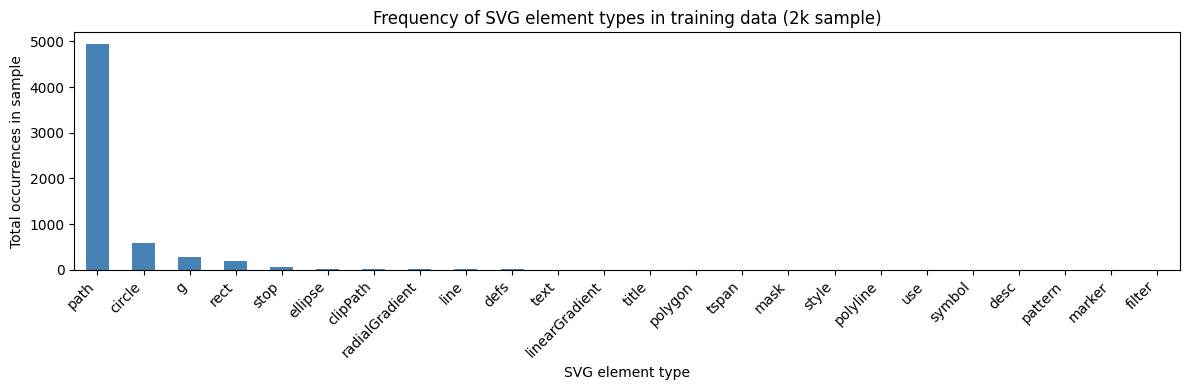

In [19]:
# Count how often each SVG element type appears across the sample
# svg, g, path, rect, circle, ellipse,
# line, polyline, polygon, defs, use,
# symbol, clipPath, mask, linearGradient,
# radialGradient, stop, text, tspan, title,
# desc, style, pattern, marker, filter
ALLOWED_TAGS = [
    "g", "path", "rect", "circle", "ellipse",
    "line", "polyline", "polygon", "defs", "use",
    "symbol", "clipPath", "linearGradient", "mask",
    "radialGradient", "stop", "text", "tspan", "title",
    "desc", "style", "pattern", "marker", "filter"
]


tag_counts = {}
for tag in ALLOWED_TAGS:
    total = sample_for_structure["svg"].apply(
        lambda s: count_element(s, tag)
    ).sum()
    tag_counts[tag] = total

# Sort by frequency and display
tag_series = pd.Series(tag_counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
tag_series.plot(kind="bar", ax=ax, color="steelblue", edgecolor="none")
ax.set_xlabel("SVG element type")
ax.set_ylabel("Total occurrences in sample")
ax.set_title("Frequency of SVG element types in training data (2k sample)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 9. Check for disallowed elements

The competition disallows some tags and any external references (href/src
pointing outside the SVG).

If the training data contains these, the model may learn to generate them
and score zero on those outputs, so they should be filtered out.

In [20]:
# scripts, event handlers, animation, foreignObject, external references
DISALLOWED_TAGS = [
    "script",
    "animate",
    "animateTransform",
    "animateMotion",
    "foreignObject",
    "set",
]

print("Training examples containing disallowed elements:\n")
for tag in DISALLOWED_TAGS:
    has_tag = train_df["svg"].str.contains(f"<{tag}", case=False, regex=False)
    n = has_tag.sum()
    print(f"  <{tag}>: {n:,} examples ({100*n/len(train_df):.2f}%)")

Training examples containing disallowed elements:

  <script>: 0 examples (0.00%)
  <animate>: 0 examples (0.00%)
  <animateTransform>: 0 examples (0.00%)
  <animateMotion>: 0 examples (0.00%)
  <foreignObject>: 0 examples (0.00%)
  <set>: 0 examples (0.00%)


In [21]:
# Also check for external references
# External references look like href="http..." or src="http..."
has_external = train_df["svg"].str.contains(r'href=["\']http', case=False, regex=True)
n_external = has_external.sum()
print(f"Examples with external href references: {n_external:,}")

Examples with external href references: 0


## 6. XML validity check

The competition requires SVGs to parse as valid XML.
Check what fraction of the training SVGs are valid XML right now.

Any training example that isn't valid XML is teaching the model to
generate invalid output and should be dropped.

In [22]:
def is_valid_xml(svg_str: str) -> bool:
    """Return True if the string parses as valid XML.

    Use Python's built-in xml.etree.ElementTree
    Should be strict enough to also pass competition's XML check
    """
    try:
        root = ET.fromstring(svg_str)
        # Confirm the root tag is actually <svg>
        return root.tag.lower().endswith("svg")
    except ET.ParseError:
        return False


# Run on a sample
validity_sample = train_df.sample(n=2000, random_state=42)
is_valid = validity_sample["svg"].apply(is_valid_xml)

n_valid   = is_valid.sum()
n_invalid = (~is_valid).sum()
print(f"Valid XML   : {n_valid:,} ({100*n_valid/len(validity_sample):.1f}%)")
print(f"Invalid XML : {n_invalid:,} ({100*n_invalid/len(validity_sample):.1f}%)")

Valid XML   : 2,000 (100.0%)
Invalid XML : 0 (0.0%)


In [23]:
# If there are invalid ones, look at what's wrong with a few
invalid_examples = validity_sample[~is_valid]

if len(invalid_examples) > 0:
    print("Example invalid SVGs (first 200 chars each):\n")
    for i, (_, row) in enumerate(invalid_examples.head(3).iterrows()):
        print(f"Example {i+1}:")
        print(f"  Prompt: {row['prompt']}")
        print(f"  SVG start: {row['svg'][:200]}")
        print()

## 7. Renderability check

A valid XML SVG can still
fail to render if it has missing required attributes or malformed path data.

Use `cairosvg` to actually render a sample of SVGs to PNG.
This is the same renderer the competition uses for scoring.

In [24]:
import cairosvg
import io

def is_renderable(svg_str: str) -> bool:
    """Return True if cairosvg can render this SVG without error.

    Render to a bytes buffer (no file written to disk)
    If cairosvg raises any exception, the SVG fails the render gate
    and would score zero in the competition.
    """
    try:
        cairosvg.svg2png(
            bytestring=svg_str.encode("utf-8"),
            output_width=256,
            output_height=256
        )
        return True
    except Exception:
        return False


# Check a small sample (rendering can be slow)
render_sample = train_df.sample(n=500, random_state=42)
is_renderable_series = render_sample["svg"].apply(is_renderable)

n_render_ok   = is_renderable_series.sum()
n_render_fail = (~is_renderable_series).sum()
print(f"Renderable     : {n_render_ok:,} ({100*n_render_ok/len(render_sample):.1f}%)")
print(f"Render failures: {n_render_fail:,} ({100*n_render_fail/len(render_sample):.1f}%)")

Renderable     : 500 (100.0%)
Render failures: 0 (0.0%)


## 8. SVG length analysis

The model generates SVG as a sequence of tokens. `max_seq_length` in training
caps how many tokens fit in one example. If an example exceeds this limit,
it gets truncated mid-SVG, which is actively harmful because it teaches
the model that cutting off mid-path is acceptable output.

So the goal here is to find a character length threshold where most examples
fit comfortably within a reasonable token budget, while keeping as much training data
as possible.

In [26]:
train_df["svg_len"] = train_df["svg"].str.len()

stats = train_df["svg_len"].describe(percentiles=[.25, .50, .75, .90, .95, .99])
print("SVG character length statistics:")
print(stats.round(0).astype(int))

SVG character length statistics:
count    50000
mean      2524
std       1774
min         91
25%       1125
50%       2110
75%       3530
90%       5100
95%       6078
99%       7514
max      15937
Name: svg_len, dtype: int64


## 9. Estimate token lengths

99% of the training samples seem to be under 8000 characters (~7514). Given that 1 token ≈ 4 characters ([OpenAI Help Center](https://help.openai.com/en/articles/4936856-what-are-tokens-and-how-to-count-them)), the `max_seq_length` of 2048 used in the tutorial could cover ~2048x4 = ~8000.

This looks like it would be sufficient to handle 99% of the training samples, but character count estimate isn't actually exactly how token count is determined. It also doesnt account for the prompt itself that will take additional tokens.

Use the tokenizer to see how many tokens the samples would really take.


In [6]:
%pip install -q transformers

In [7]:
from transformers import AutoTokenizer

# Checking with Qwen2.5-1.5B (chosen model, should hopefully be less train time than 2B)
# Load just the tokenizer (no GPU needed, fast to load)
MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
print(f"Tokenizer loaded: {MODEL_ID}")
print(f"Vocab size: {tokenizer.vocab_size:,}")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: Qwen/Qwen2.5-1.5B-Instruct
Vocab size: 151,643


In [8]:
# Chat template that will be used during training
# Define here so token counting matches actual training format
#
# Format: system message + user prompt + assistant SVG response
# Model sees all three parts during training and learns to generate
# the assistant (SVG) portion given the system + user portions.

SYSTEM_PROMPT = (
    "You are an SVG code generator. "
    "Given a description, return only valid SVG code with a single root <svg> element. "
    "The canvas must be 256x256 pixels. Do not include any explanation."
)

def format_training_example(prompt: str, svg: str) -> str:
    """Format a (prompt, svg) pair into the chat template.

    apply_chat_template handles the model-specific special tokens
    (<|im_start|>, <|im_end|> for Qwen)
    """
    messages = [
        {"role": "system",    "content": SYSTEM_PROMPT},
        {"role": "user",      "content": prompt},
        {"role": "assistant", "content": svg},
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False) # tokenize=False returns the formatted string without converting to token IDs

# Preview what one formatted example looks like
example_text = format_training_example(
    prompt=train_df.loc[0, "prompt"],
    svg=train_df.loc[0, "svg"]
)
print(example_text[:600])
print("...")
print(f"\nTotal formatted length: {len(example_text)} characters")

<|im_start|>system
You are an SVG code generator. Given a description, return only valid SVG code with a single root <svg> element. The canvas must be 256x256 pixels. Do not include any explanation.<|im_end|>
<|im_start|>user
The image features two orange squares with a microphone icon and an arrow connecting them, set against a white background.<|im_end|>
<|im_start|>assistant
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="#FF6A00" fill-opacity="1.0"  filling="0" d="M93.30000305175781 21.20000457763672 L93.30000305175781 80.4
...

Total formatted length: 4575 characters


In [9]:
import numpy as np

# Sample 2,000 rows to estimate token length distribution.
# Tokenizing all 50k rows on CPU is slow. 2k should give decent estimate.
SAMPLE_N   = 2000
sample_df  = train_df.sample(n=SAMPLE_N, random_state=42).reset_index(drop=True)

token_lengths = []
for _, row in sample_df.iterrows():
    formatted = format_training_example(row["prompt"], row["svg"])
    token_lengths.append(len(tokenizer.encode(formatted)))

token_lengths = np.array(token_lengths)

print("Token length statistics (prompt + SVG, formatted):")
for pct in [50, 75, 90, 95, 99, 100]:
    print(f"  p{pct:3d}: {np.percentile(token_lengths, pct):.0f} tokens")

Token length statistics (prompt + SVG, formatted):
  p 50: 1934 tokens
  p 75: 3558 tokens
  p 90: 5049 tokens
  p 95: 5974 tokens
  p 99: 7320 tokens
  p100: 8011 tokens


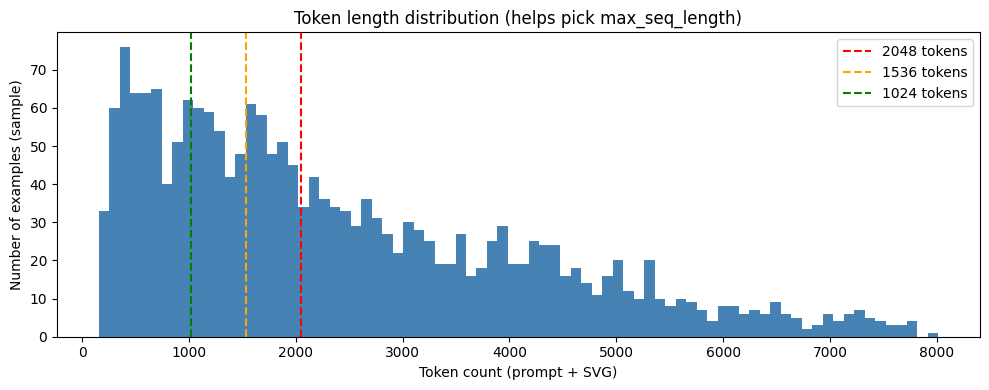

Fraction of sampled examples fitting within max_seq_length:
   1024 tokens: 25.2% of examples fit
   1536 tokens: 39.1% of examples fit
   2048 tokens: 52.5% of examples fit
   2560 tokens: 61.9% of examples fit
   3072 tokens: 69.5% of examples fit


In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(token_lengths, bins=80, color="steelblue", edgecolor="none")
ax.axvline(2048, color="red",    linestyle="--", linewidth=1.5, label="2048 tokens")
ax.axvline(1536, color="orange", linestyle="--", linewidth=1.5, label="1536 tokens")
ax.axvline(1024, color="green",  linestyle="--", linewidth=1.5, label="1024 tokens")
ax.set_xlabel("Token count (prompt + SVG)")
ax.set_ylabel("Number of examples (sample)")
ax.set_title("Token length distribution (helps pick max_seq_length)")
ax.legend()
plt.tight_layout()
plt.show()

print("Fraction of sampled examples fitting within max_seq_length:")
for limit in [1024, 1536, 2048, 2560, 3072]:
    pct = 100 * (token_lengths <= limit).mean()
    print(f"  {limit:5d} tokens: {pct:.1f}% of examples fit")

### Observation: SVG tokenizes much worse than expected

Normal text tokenizes at about 1 token ≈ 4 characters
But looking at the statistics, it looks like 99th percentile are 7514 characters and 7320 tokens, which is much closer to 1 token = 1 character (4x less).

The reason could be that the Qwen tokenizer was trained primarily on natural language and general code, so it has efficient tokens for common English words and patterns, but SVG path data looks completely different. SVG paths have long sequences of decimal numbers like:

```
d="M93.30000305175781 21.20000457763672 L93.30000305175781 80.4..."
```

The tokenizer has no efficient representation for strings like `123.456`, so it splits each decimal number into individual digits and punctuation. According to Claude, this could look like:

```
"123.456"  →  ["123", ".", "4", "5", "6"]   ~= 5 tokens for 7 characters
```

This means with the `max_seq_length` of 2048 tokens, only 52.5% of examples fit from the 2k sampled, about half as many as expected.

This is a problem, because a truncated SVG in training actively harms the
model by teaching it that broken, incomplete SVGs are acceptable.

### **A Potential Solution**
Since this sub-pixel precision is likely visually not noticable but very expensive token-wise, going to try to round floating point coordinate decimal values before training.

## 10. Try to reduce token count: Coordinate rounding

As identified in Section 5, SVG path data tokenizes very inefficiently because
decimal coordinates like `123.456` get split into multiple tokens.

Objective is to round all floating point numbers in the SVG strings before training.
This should not affect quality of results because:
- The competition renders at 256×256 pixels, so sub-pixel differences are not likely to make a big impact.
- Improving the token count means that longer + more samples can be trained, improving the model's capabilities

Fingers crossed this approach reduces a lot!

In [15]:
import re

def round_svg_coordinates(svg_str: str, decimals: int = 1) -> str:
    """Round all floating point numbers in an SVG string.

    decimals=1 keeps one decimal place as a safety margin.
    decimals=0 rounds to integers for maximum token savings.
    """
    def round_match(m):
        value   = float(m.group(0))
        rounded = round(value, decimals)
        if decimals == 0:
            return str(int(rounded))
        return str(rounded)

    return re.sub(r'-?\d+\.\d+', round_match, svg_str)


# Demo: what does rounding actually do to one example?
original = train_df.loc[0, "svg"]
rounded  = round_svg_coordinates(original, decimals=1)

print(f"Original : {len(original):,} chars, {len(tokenizer.encode(original))} tokens")
print(f"Rounded  : {len(rounded):,} chars, {len(tokenizer.encode(rounded))} tokens")
print(f"\nSample of what changes:")
# Show a short snippet where rounding had an effect
orig_snippet   = original[200:350]
rounded_snippet = round_svg_coordinates(orig_snippet, decimals=1)
print(f"  Before: {orig_snippet}")
print(f"  After : {rounded_snippet}")

Original : 4,183 chars, 3916 tokens
Rounded  : 1,645 chars, 1378 tokens

Sample of what changes:
  Before: 30000305175781 80.4000015258789 L21.20000457763672 80.4000015258789 L21.20000457763672 179.60000610351562 L120.4000015258789 179.60000610351562 L120.4
  After : 30000305175781 80.4 L21.2 80.4 L21.2 179.6 L120.4 179.6 L120.4


In [17]:
# Measure token reduction across the 2k sample
token_lengths_rounded = []
for _, row in sample_df.iterrows():
    rounded_svg = round_svg_coordinates(row["svg"], decimals=1)
    formatted   = format_training_example(row["prompt"], rounded_svg)
    token_lengths_rounded.append(len(tokenizer.encode(formatted)))

token_lengths_rounded = np.array(token_lengths_rounded)

print("Token length comparison (2k sample):")
print(f"  {'Percentile':>10}  {'Before':>8}  {'After':>8}  {'Saved':>6}")
print("  " + "-" * 38)
for pct in [50, 75, 90, 95, 99]:
    before = np.percentile(token_lengths, pct)
    after  = np.percentile(token_lengths_rounded, pct)
    print(f"  p{pct:3d}        {before:>8.0f}  {after:>8.0f}  {before-after:>6.0f}")

before_pct = 100 * (token_lengths         <= 2048).mean()
after_pct  = 100 * (token_lengths_rounded <= 2048).mean()
print(f"\nFit within 2048 tokens: {before_pct:.1f}% -> {after_pct:.1f}% after rounding")

Token length comparison (2k sample):
  Percentile    Before     After   Saved
  --------------------------------------
  p 50            1934       921    1014
  p 75            3558      1418    2139
  p 90            5049      1943    3106
  p 95            5974      2279    3695
  p 99            7320      3021    4299

Fit within 2048 tokens: 52.5% -> 92.3% after rounding


### Observation: impact of coordinate rounding

The table above quantifies the token savings from rounding. Even rounding to
1 decimal place (keeping `123.5` instead of `123.456`) saves a meaningful number
of tokens per example, and the percentage fitting within 2048 increases significantly from 52.5% to 92.3%.

Rounding to 0 decimal places (integers only) would save even more, but 1 decimal
place is a safer choice to preserve more precision for cases where coordinates
might need to align exactly like matching endpoints or connections.

### Decision: Apply this to full dataset before saving & training!

## 11. Re-analyze lengths rounded SVGs

Get more accurate numbers for choosing max chararacters allowed to fit within 2048 tokens on the new rounded dataset.

In [27]:
print("Applying coordinate rounding to full training set for analysis...")
train_df["svg_rounded"] = train_df["svg"].apply(
    lambda s: round_svg_coordinates(s, decimals=1)
)
train_df["svg_len_rounded"] = train_df["svg_rounded"].str.len()

print(f"Done. Rounded {len(train_df):,} SVGs.")
print(f"\nCharacter length comparison (full dataset):")
print(f"  {'':10}  {'Original':>10}  {'Rounded':>10}  {'Saved':>8}")
print("  " + "-" * 44)
for pct in [50, 75, 90, 95, 99]:
    orig = train_df["svg_len"].quantile(pct/100)
    rnd  = train_df["svg_len_rounded"].quantile(pct/100)
    print(f"  p{pct:<7}    {orig:>10.0f}  {rnd:>10.0f}  {orig-rnd:>8.0f}")

Applying coordinate rounding to full training set for analysis...
Done. Rounded 50,000 SVGs.

Character length comparison (full dataset):
                Original     Rounded     Saved
  --------------------------------------------
  p50               2110        1028      1082
  p75               3530        1534      1996
  p90               5100        2115      2985
  p95               6078        2472      3606
  p99               7514        3216      4298


In [33]:
# How many examples survive at different character thresholds, using ROUNDED lengths?
# Compare this to the original numbers to see how many more samples can be kept with rounding

thresholds = [2000, 2500, 3000, 4000, 5000]

print(f"{'Threshold':>12}  {'Original kept':>14}  {'Rounded kept':>13}  {'Gain':>6}")
print("-" * 52)
for t in thresholds:
    orig_kept    = (train_df["svg_len"]         <= t).sum()
    rounded_kept = (train_df["svg_len_rounded"] <= t).sum()
    gain         = rounded_kept - orig_kept
    orig_pct     = 100 * orig_kept    / len(train_df)
    rounded_pct  = 100 * rounded_kept / len(train_df)
    print(f"{t:>12,}  {orig_kept:>8,} ({orig_pct:4.1f}%)  {rounded_kept:>7,} ({rounded_pct:4.1f}%)  +{gain:>5,}")

   Threshold   Original kept   Rounded kept    Gain
----------------------------------------------------
       2,000    23,757 (47.5%)   43,891 (87.8%)  +20,134
       2,500    29,082 (58.2%)   47,651 (95.3%)  +18,569
       3,000    33,568 (67.1%)   49,308 (98.6%)  +15,740
       4,000    40,315 (80.6%)   49,668 (99.3%)  +9,353
       5,000    44,683 (89.4%)   49,786 (99.6%)  +5,103


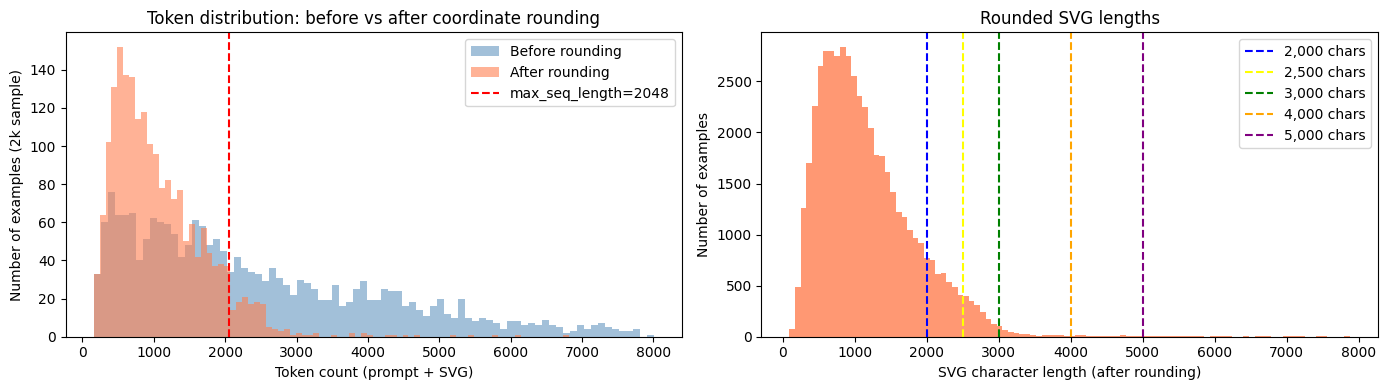

In [34]:
# Plot 1: Token distribution before vs after rounding (on the 2k sample)
# Plot 2: Character length distribution of rounded SVGs with threshold candidates
# Both together help choose the right SVG_MAX_CHARS

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# plot 1
axes[0].hist(token_lengths,         bins=80, alpha=0.5, color="steelblue",
             label="Before rounding", edgecolor="none")
axes[0].hist(token_lengths_rounded, bins=80, alpha=0.6, color="coral",
             label="After rounding",  edgecolor="none")
axes[0].axvline(2048, color="red", linestyle="--", linewidth=1.5,
                label="max_seq_length=2048")
axes[0].set_xlabel("Token count (prompt + SVG)")
axes[0].set_ylabel("Number of examples (2k sample)")
axes[0].set_title("Token distribution: before vs after coordinate rounding")
axes[0].legend()

# plot 2
axes[1].hist(train_df[train_df["svg_len_rounded"] <= 8000]["svg_len_rounded"],
             bins=100, color="coral", edgecolor="none", alpha=0.8)
for thresh, color, label in [
    (2000, "blue",  "2,000"),
    (2500, "yellow",  "2,500"),
    (3000, "green",  "3,000"),
    (4000, "orange", "4,000"),
    (5000, "purple", "5,000"),
]:
    axes[1].axvline(thresh, color=color, linestyle="--", linewidth=1.5,
                    label=f"{label} chars")
axes[1].set_xlabel("SVG character length (after rounding)")
axes[1].set_ylabel("Number of examples")
axes[1].set_title("Rounded SVG lengths")
axes[1].legend()

plt.tight_layout()
plt.show()

In [35]:
# Final check: what token lengths are at each character threshold?
# Want to pick a threshold where at least p95 tokens comfortably fits under 2048.

print("Token lengths at each character threshold (rounded SVGs, 500-sample estimate):\n")
print(f"  {'Char limit':>12}  {'Examples kept':>14}  {'p50 tok':>8}  {'p90 tok':>8}  {'p95 tok':>8}  {'% fit 2048':>11}")
print("  " + "-" * 70)

for char_limit in [2000, 2500, 3000, 4000, 5000]:
    subset = train_df[train_df["svg_len_rounded"] <= char_limit].sample(
        n=min(500, (train_df["svg_len_rounded"] <= char_limit).sum()),
        random_state=42
    )
    toks = []
    for _, row in subset.iterrows():
        fmt = format_training_example(row["prompt"], row["svg_rounded"])
        toks.append(len(tokenizer.encode(fmt)))
    toks = np.array(toks)
    n_kept  = (train_df["svg_len_rounded"] <= char_limit).sum()
    pct_fit = 100 * (toks <= 2048).mean()
    print(f"  {char_limit:>12,}  {n_kept:>10,} ({100*n_kept/len(train_df):4.1f}%)  "
          f"{np.percentile(toks,50):>8.0f}  {np.percentile(toks,90):>8.0f}  "
          f"{np.percentile(toks,95):>8.0f}  {pct_fit:>9.1f}%")

Token lengths at each character threshold (rounded SVGs, 500-sample estimate):

    Char limit   Examples kept   p50 tok   p90 tok   p95 tok   % fit 2048
  ----------------------------------------------------------------------
         2,000      43,891 (87.8%)       820      1423      1603      100.0%
         2,500      47,651 (95.3%)       881      1703      1927       98.2%
         3,000      49,308 (98.6%)       962      1874      2091       93.4%
         4,000      49,668 (99.3%)       952      2062      2339       89.4%
         5,000      49,786 (99.6%)       933      1856      2304       92.8%


### Observation: Use token count rather than char chount

There seems to be a lot of variance in tokens/character for the SVGs. For example, in the table above, the samples for the 5,000 char limit fit better in the 2048 token threshold than for the 4,000 char limit samples. SVGs that use other tags like rect and circle might take fewer tokens than ones that use more complex paths, even with similar char lengths.

### Decision: Filter the training dataset based on token count with prompt, rather than char length

## 12. Build the filtered training dataset

Apply all filters in one pipeline and save the result.

Filter Criteria:
1. Non-empty prompt and SVG
2. SVG starts with `<svg`
3. No disallowed elements
4. Valid XML
5. Token count <= TOKEN_LIMIT (direct token filter, replaces character filter)

In [36]:
TOKEN_LIMIT = 1900  # leaves ~148 token buffer below max_seq_length=2048

print(f"Starting with {len(train_df):,} training examples.")
filtered = train_df.copy()

# Step 1: remove nulls and empty strings
filtered = filtered[
    filtered["prompt"].notna() & (filtered["prompt"].str.strip() != "") &
    filtered["svg"].notna()    & (filtered["svg"].str.strip() != "")
]
print(f"After removing nulls/empty      : {len(filtered):,}")

# Step 2: SVG must start with <svg
filtered = filtered[
    filtered["svg"].str.lstrip().str.lower().str.startswith("<svg")
]
print(f"After requiring <svg start      : {len(filtered):,}")

# Step 3: remove disallowed elements
disallowed_pattern = "|".join([f"<{tag}" for tag in DISALLOWED_TAGS])
has_disallowed     = filtered["svg"].str.contains(disallowed_pattern, case=False, regex=True)
filtered           = filtered[~has_disallowed]
print(f"After removing disallowed tags  : {len(filtered):,}")

# Step 4: XML validity
print("Checking XML validity...")
xml_valid = filtered["svg"].apply(is_valid_xml)
filtered  = filtered[xml_valid]
print(f"After XML validity check        : {len(filtered):,}")

# Step 5: token count filter (uses pre-computed token_count column)
# If token_count wasn't computed yet (e.g. re-running from scratch), compute it now on the rounded SVGs
if "token_count" not in filtered.columns:
    print("Computing token counts (this takes a few minutes)...")
    filtered["token_count"] = filtered.apply(
        lambda row: len(tokenizer.encode(
            format_training_example(row["prompt"], row["svg_rounded"])
        )), axis=1
    )

filtered = filtered[filtered["token_count"] <= TOKEN_LIMIT]
print(f"After token filter (<={TOKEN_LIMIT})     : {len(filtered):,}")

print(f"\nFinal: {len(filtered):,} examples ({100*len(filtered)/len(train_df):.1f}% of original)")

Starting with 50,000 training examples.
After removing nulls/empty      : 50,000
After requiring <svg start      : 50,000
After removing disallowed tags  : 50,000
Checking XML validity...
After XML validity check        : 50,000
Computing token counts (this takes a few minutes)...
After token filter (<=1900)     : 44,836

Final: 44,836 examples (89.7% of original)


In [37]:
# Confirm token distribution on the final filtered set
final_toks = filtered["token_count"].values
print("Token counts in final filtered set:")
for pct in [50, 75, 90, 95, 99]:
    print(f"  p{pct}: {np.percentile(final_toks, pct):.0f} tokens")
pct_fit = 100 * (final_toks <= 2048).mean()
print(f"\n{pct_fit:.1f}% of examples fit within max_seq_length=2048")

Token counts in final filtered set:
  p50: 856 tokens
  p75: 1228 tokens
  p90: 1558 tokens
  p95: 1711 tokens
  p99: 1857 tokens

100.0% of examples fit within max_seq_length=2048


## Observation: 2048 might not be needed
With this filter, 100% of all examples fit within the max sequence length. However, the next lowest sequence length would be 1792, and this is still higher than p95, meaning only 5% of the samples might be truncated, and they would probably only be truncated by < 100 tokens.
Since training will happen on the free T4 from Google Colab, the memory and time savings of reducing the sequence length might not be worth the benefit of fully capturing those 5% of samples.

## Decision: Let p95 determine max_seq_length

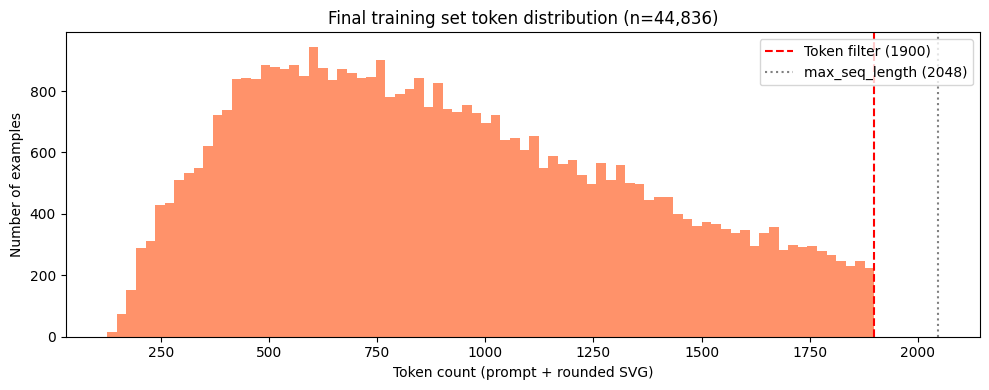

In [38]:
# Visual confirmation: token distribution of the final training set
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(final_toks, bins=80, color="coral", edgecolor="none", alpha=0.85)
ax.axvline(TOKEN_LIMIT, color="red",  linestyle="--", linewidth=1.5,
           label=f"Token filter ({TOKEN_LIMIT})")
ax.axvline(2048,        color="gray", linestyle=":",  linewidth=1.5,
           label="max_seq_length (2048)")
ax.set_xlabel("Token count (prompt + rounded SVG)")
ax.set_ylabel("Number of examples")
ax.set_title(f"Final training set token distribution (n={len(filtered):,})")
ax.legend()
plt.tight_layout()
plt.show()

## 13. Visual spot-check of filtered examples

Before saving, render a few examples to confirm coordinate rounding
didn't visually break anything.

In [41]:
# render 5 random examples to confirm rounded SVGs still look correct
from IPython.display import HTML

spot_check = filtered.sample(n=5, random_state=42).reset_index(drop=True)

html_parts = []
for _, row in spot_check.iterrows():
    html_parts.append(f"""
    <div style='display:inline-block; margin:10px; vertical-align:top; width:200px;'>
        <p style='font-size:11px; color:#555; margin:4px 0;'>{row['prompt'][:80]}</p>
        {row['svg_rounded']}
    </div>
    """)

display(HTML("".join(html_parts)))

## 14. Save the filtered dataset to HuggingFace

Save `train_filtered.csv` back to the HuggingFace repo.
Notebook 2 loads from this file for training.

Note: uploading requires write access. Set your HuggingFace token in Colab secrets (key icon in left sidebar) as `HF_TOKEN`.

In [42]:
# Save filtered dataset — use svg_rounded as the svg column since that's
# what token counts were measured on and what we'll train on
filtered_clean = filtered[["id", "prompt"]].copy()
filtered_clean["svg"] = filtered["svg_rounded"]
filtered_clean = filtered_clean.reset_index(drop=True)

LOCAL_FILTERED_PATH = "train_filtered.csv"
filtered_clean.to_csv(LOCAL_FILTERED_PATH, index=False)
print(f"Saved locally: {LOCAL_FILTERED_PATH} ({len(filtered_clean):,} rows)")
print(f"Columns: {list(filtered_clean.columns)}")
print(f"\nSample SVG (first 200 chars):")
print(filtered_clean.loc[0, 'svg'][:200])

Saved locally: train_filtered.csv (44,836 rows)
Columns: ['id', 'prompt', 'svg']

Sample SVG (first 200 chars):
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="#FF6A00" fill-opacity="1.0"  filling="0" d="M93.3 21.2 L93.3 80.4 L21.2 80.4 L21.2 17


In [43]:
# Upload to HuggingFace
# Requires HF_TOKEN with write access set in Colab secrets (key icon, left sidebar)
from huggingface_hub import HfApi
from google.colab import userdata
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

api = HfApi(token=os.environ["HF_TOKEN"])
api.upload_file(
    path_or_fileobj=LOCAL_FILTERED_PATH,
    path_in_repo="train_filtered.csv",
    repo_id=HF_DATASET_REPO,
    repo_type="dataset",
    commit_message=(
        f"Add filtered training set "
        f"({len(filtered_clean):,} rows, "
        f"token filter <={TOKEN_LIMIT}, "
        f"coords rounded to 1dp)"
    )
)
print(f"Uploaded train_filtered.csv to {HF_DATASET_REPO}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  train_filtered.csv          :   2%|2         | 1.09MB / 53.7MB            

Uploaded train_filtered.csv to aagoluoglu/text-to-svg


## 15. Summary and decisions for Notebook 2

This cell auto-generates a summary of the decisions made in this notebook.
The output below is what goes into Notebook 2's `CONFIG` block.

In [46]:
p95_final = int(np.percentile(final_toks, 95))
p99_final = int(np.percentile(final_toks, 99))

# Round p95 up to nearest 256 — GPU memory is managed in 256-token chunks
recommended_seq_len = ((p95_final // 256) + 1) * 256

print("=" * 58)
print("DECISIONS SUMMARY & Notebook 2 CONFIG")
print("=" * 58)
print(f"  Training examples (raw)         : {len(train_df):,}")
print(f"  Training examples (filtered)    : {len(filtered_clean):,}")
print(f"  Filter method                   : token count <= {TOKEN_LIMIT}")
print(f"  Coordinate rounding             : 1 decimal place")
print()
print(f"  Token length p95 (final set)    : {p95_final}")
print(f"  Token length p99 (final set)    : {p99_final}")
print(f"  Recommended max_seq_length      : {recommended_seq_len}")
print()
print(f"  Model                           : Qwen/Qwen2.5-1.5B-Instruct")
print(f"  Training data file              : {HF_DATASET_REPO}/train_filtered.csv")
print("=" * 58)

DECISIONS SUMMARY & Notebook 2 CONFIG
  Training examples (raw)         : 50,000
  Training examples (filtered)    : 44,836
  Filter method                   : token count <= 1900
  Coordinate rounding             : 1 decimal place

  Token length p95 (final set)    : 1711
  Token length p99 (final set)    : 1857
  Recommended max_seq_length      : 1792

  Model                           : Qwen/Qwen2.5-1.5B-Instruct
  Training data file              : aagoluoglu/text-to-svg/train_filtered.csv
